In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pandas.plotting import scatter_matrix
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

sns.set(color_codes=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [2]:
one = pd.read_csv(
    "./input/1.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
one.drop('Sequence', axis=1, inplace=True)

two = pd.read_csv(
    "./input/2.csv"
    ,names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
two.drop('Sequence', axis=1, inplace=True)

three = pd.read_csv(
    "./input/3.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
three.drop('Sequence', axis=1, inplace=True)

four = pd.read_csv(
    "./input/4.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
four.drop('Sequence', axis=1, inplace=True)

five = pd.read_csv(
    "./input/5.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
five.drop('Sequence', axis=1, inplace=True)

six = pd.read_csv(
    "./input/6.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
six.drop('Sequence', axis=1, inplace=True)

seven = pd.read_csv(
    "./input/7.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
seven.drop('Sequence', axis=1, inplace=True)

eight = pd.read_csv(
    "./input/8.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eight.drop('Sequence', axis=1, inplace=True)

nine = pd.read_csv(
    "./input/9.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
nine.drop('Sequence', axis=1, inplace=True)

ten = pd.read_csv(
    "./input/10.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
ten.drop('Sequence', axis=1, inplace=True)

eleven = pd.read_csv(
    "./input/11.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eleven.drop('Sequence', axis=1, inplace=True)

twelve = pd.read_csv(
    "./input/12.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
twelve.drop('Sequence', axis=1, inplace=True)

thirteen = pd.read_csv(
    "./input/13.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
thirteen.drop('Sequence', axis=1, inplace=True)

fourteen = pd.read_csv(
    "./input/14.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fourteen.drop('Sequence', axis=1, inplace=True)

fifteen = pd.read_csv(
    "./input/15.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fifteen.drop('Sequence', axis=1, inplace=True)

In [3]:
one['Person'] = 1
two['Person'] = 2
three['Person'] = 3
four['Person'] = 4
five['Person'] = 5
six['Person'] = 6
seven['Person'] = 7
eight['Person'] = 8
nine['Person'] = 9
ten['Person'] = 10
eleven['Person'] = 11
twelve['Person'] = 12
thirteen['Person'] = 13
fourteen['Person'] = 14
fifteen['Person'] = 15   #15 Participants and 7 Activities


frames = [one, two, three, four, five, six, seven, eight, nine, ten, eleven, twelve, thirteen, fourteen, fifteen]
df = pd.concat(frames)   
print(df.shape)  
print(df.head())

(1926896, 5)
   x_acceleration  y_acceleration  z_acceleration  Labels  Person
0            1502            2215            2153       1       1
1            1667            2072            2047       1       1
2            1611            1957            1906       1       1
3            1601            1939            1831       1       1
4            1643            1965            1879       1       1


* 1.4 Due to the large amount of sample data, we choose to sample randomly.And then we know briefly the basic information of the data set.

In [5]:
df_rnd = df.sample(n=100000, random_state=6758)  # Sampling randomly according to a certain number 

df_rnd_2 = df.sample(frac=0.5)
print(df_rnd_2.shape)                            # Sampling randomly according to a certain scale 

(963448, 5)


In [6]:
df_rnd = df_rnd[df_rnd['Labels'] != 0]  # There are only seven categories in the actual problem, so we remove data which are labeled 0.
print(df_rnd.shape)
print(df_rnd['Labels'].value_counts())

(99819, 5)
Labels
1    31627
7    30770
4    18590
3    11178
5     2785
2     2498
6     2371
Name: count, dtype: int64


In [7]:
print(df_rnd.dtypes, df_rnd.isna().sum())
print(df_rnd.describe())

print(df_rnd.groupby('Labels').mean())  

x_acceleration    int64
y_acceleration    int64
z_acceleration    int64
Labels            int64
Person            int64
dtype: object x_acceleration    0
y_acceleration    0
z_acceleration    0
Labels            0
Person            0
dtype: int64
       x_acceleration  y_acceleration  z_acceleration        Labels  \
count    99819.000000    99819.000000    99819.000000  99819.000000   
mean      1987.307336     2381.967471     1970.829041      3.887617   
std        111.369988      100.211564       94.573223      2.438922   
min        483.000000       74.000000     1157.000000      1.000000   
25%       1904.000000     2337.000000     1918.000000      1.000000   
50%       1991.000000     2366.000000     1988.000000      4.000000   
75%       2076.000000     2411.000000     2033.000000      7.000000   
max       2895.000000     2968.000000     4095.000000      7.000000   

             Person  
count  99819.000000  
mean       7.518589  
std        4.185780  
min        1.000000  
25%

From the above means,it seems that y_acceleration always keeps biggest regardless of seven activities.In addition, x_acceleration's maximum is label 5 and label 6 , namely "Going UpDown Stairs"and " Walking and Talking with Someone", y_acceleration's minimun is label 2, namely"Standing Up, Walking and Going updown stairs", z_acceleration's maximum is label 5, namely "Going UpDown Stairs".

# 2. Data Exploring

* 2.1 Explore relationships between attributes and visualization.

/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_7967/136514995.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],


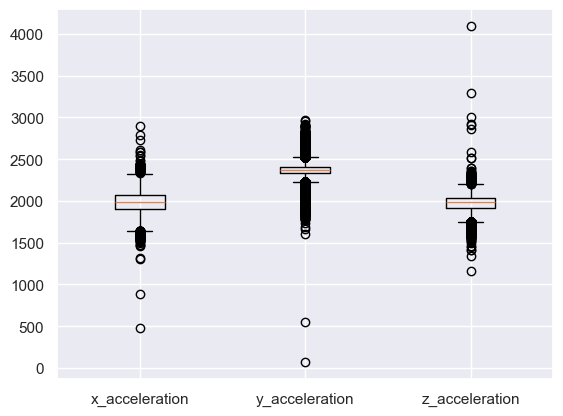

In [11]:
plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

    x_acceleration  y_acceleration  z_acceleration  Labels  Person
84            1670            2147            2079       1       1
88            1726            2203            2005       1       1
89            1778            2143            1946       1       1
90            1718            2102            2012       1       1
93            1664            2241            2064       1       1


/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_7967/3561576925.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],


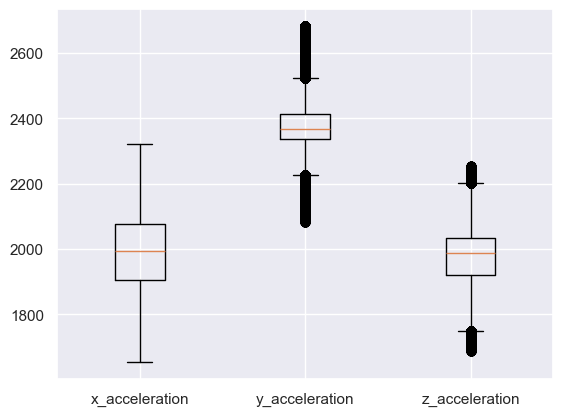

In [12]:
temp = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]  
print(temp.head())
plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

The boxplot of non-outliers for data according to zscore.

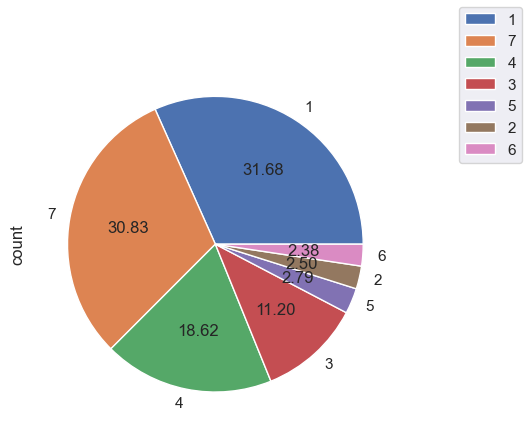

In [14]:
df_rnd['Labels'].value_counts().plot(kind='pie', autopct='%.2f')  
plt.figlegend()  
plt.show()  

According to the pie chart, it can be determined that Label 1, 4 and 7 account for the largest proportion, namely Working at Computer, Walking, Talking while Standing respectively.

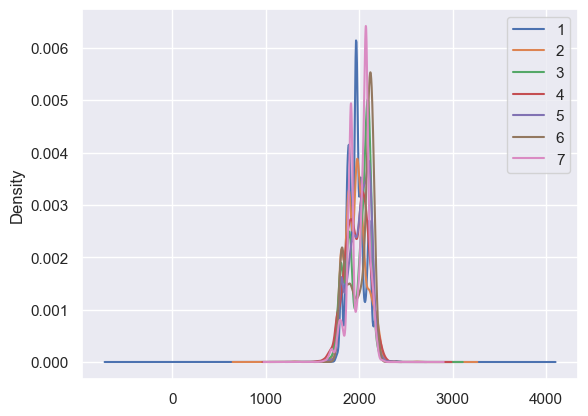

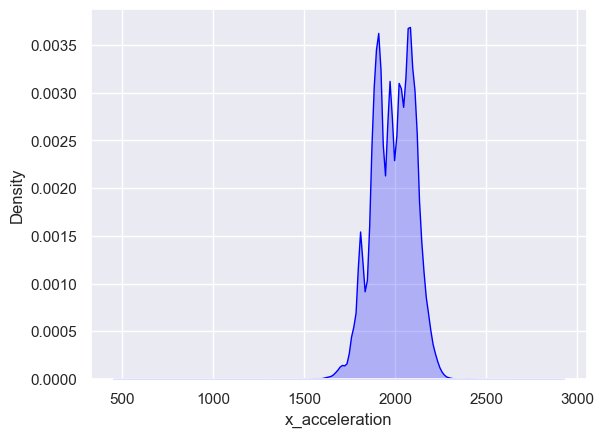

In [16]:
df_rnd.groupby('Labels')['x_acceleration'].plot.kde()   
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["x_acceleration"], fill=True, color='blue')
plt.show()

According to the kernel density,we can know that x_acceleration is between 1600 and 2300.In addition, label 7 and label 1 have the highest probability,namely Talking while Standing and Working at Computer respectively.

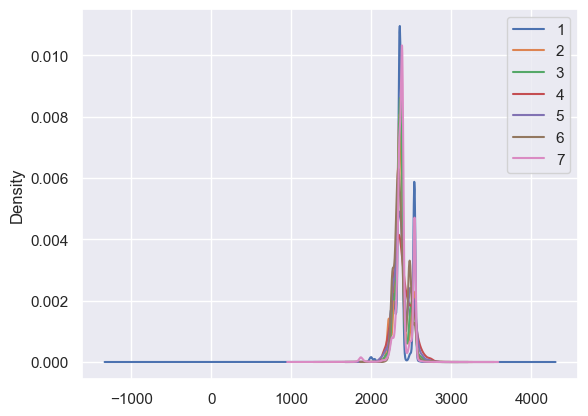

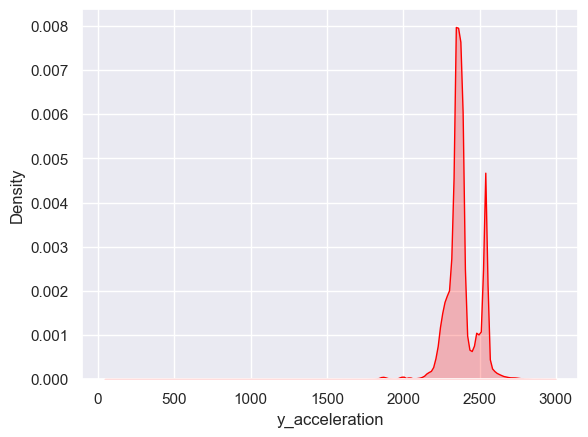

In [18]:
df_rnd.groupby('Labels')['y_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["y_acceleration"], fill=True, color='red')
plt.show()

According to the kernel density,we can know that y_acceleration is between 2200 and 2800.In addition, label 1 and label 7 have the highest probability,namely Working at Computer  and Talking while Standing respectively.

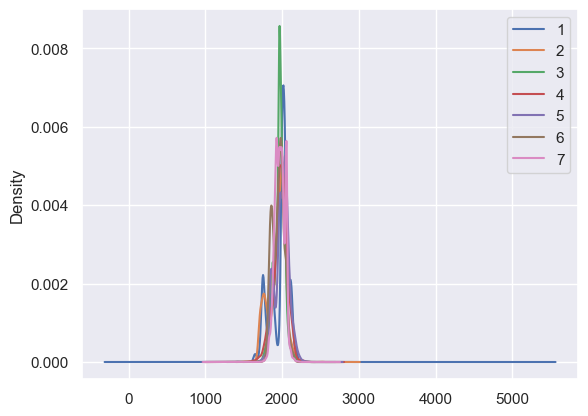

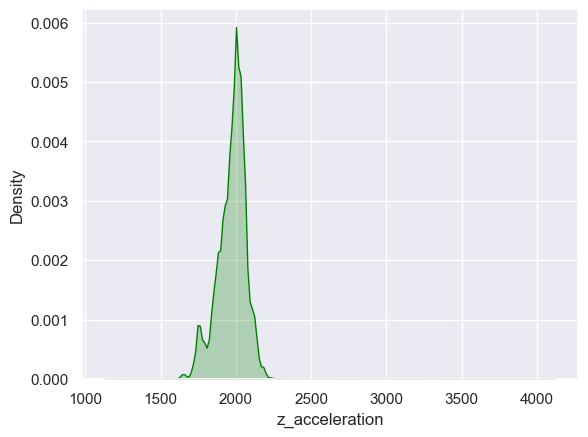

In [20]:
df_rnd.groupby('Labels')['z_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["z_acceleration"], fill=True, color='green')
plt.show()

According to the kernel density,we can know that z_acceleration is between 1600 and 2300.In addition, label 3 and label 1 have the highest probability, namely Standing and Working at Computer respectively.

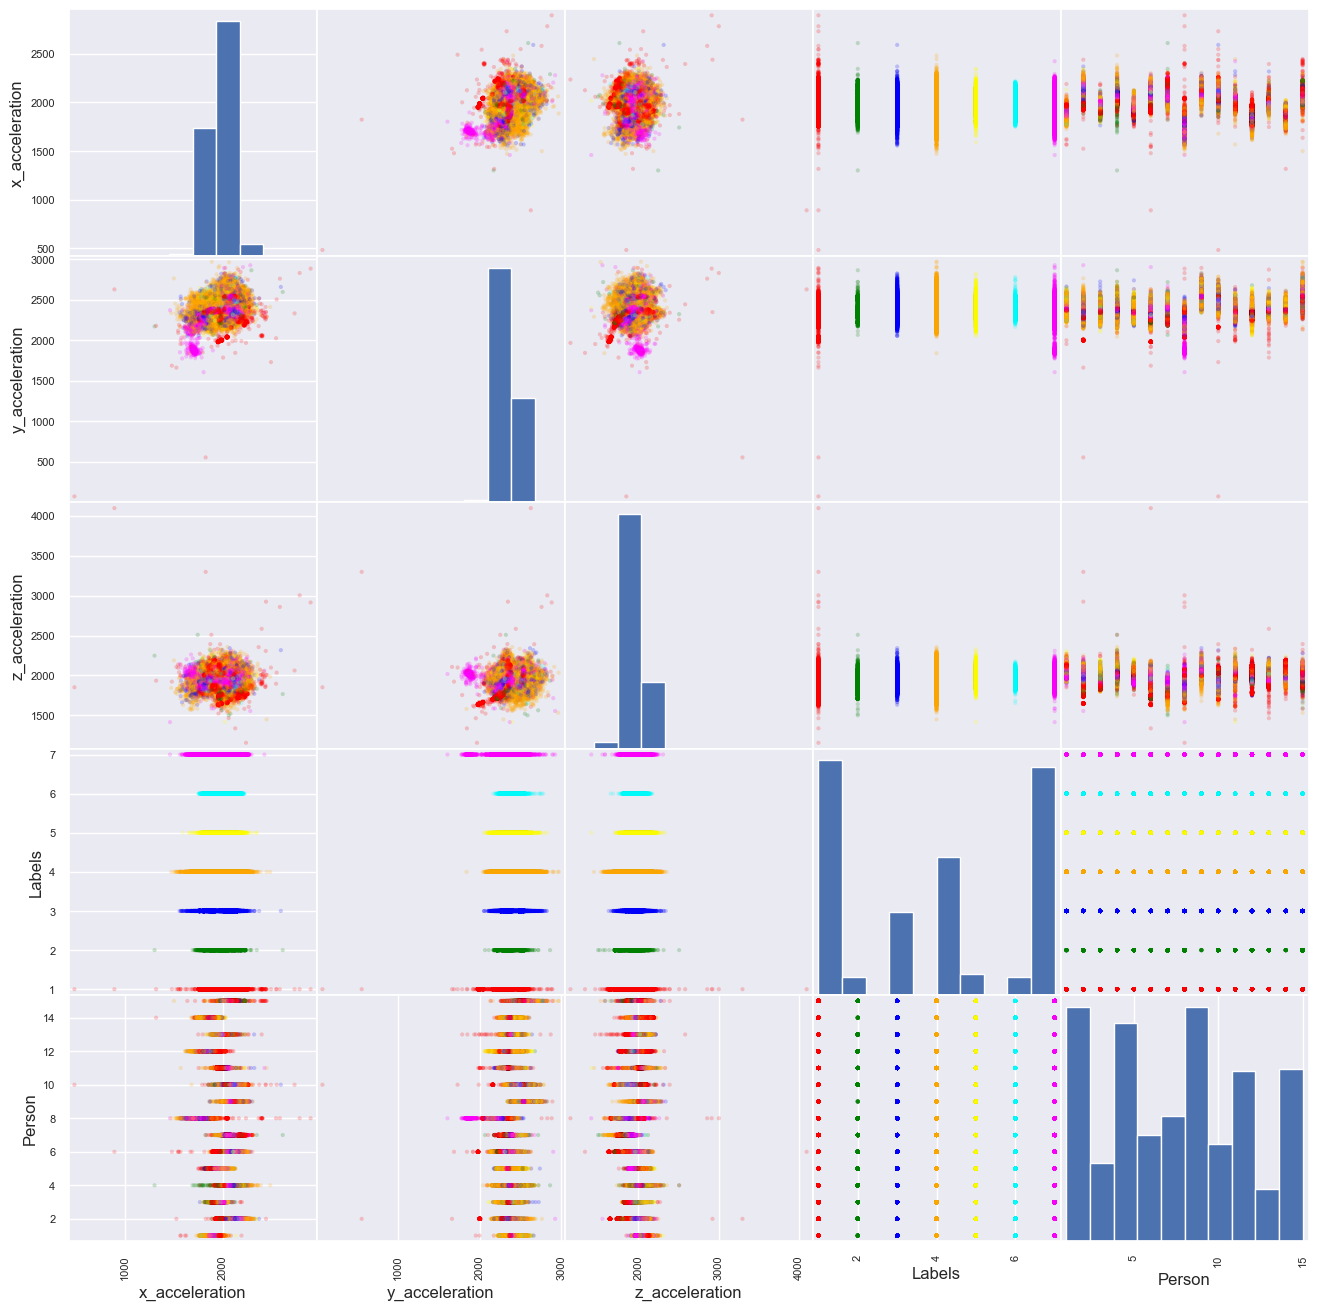

In [22]:
colors_palette = {1: 'red', 2: 'green', 3: 'blue', 4: 'orange', 5: 'yellow', 6: 'cyan', 7: 'magenta'}
colors = [colors_palette[c] for c in df_rnd['Labels']]
scatter_matrix(df_rnd, alpha=0.2, figsize=(16, 16), diagonal='hist', c=colors)
plt.show()

                x_acceleration  y_acceleration  z_acceleration    Labels  \
x_acceleration        1.000000        0.371044        0.015191  0.079724   
y_acceleration        0.371044        1.000000        0.340963  0.044100   
z_acceleration        0.015191        0.340963        1.000000  0.030303   
Labels                0.079724        0.044100        0.030303  1.000000   
Person               -0.018510        0.284180        0.127364 -0.174606   

                  Person  
x_acceleration -0.018510  
y_acceleration  0.284180  
z_acceleration  0.127364  
Labels         -0.174606  
Person          1.000000  


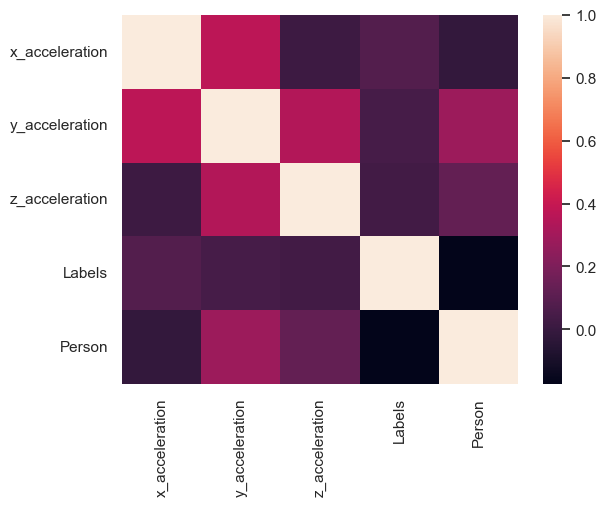

In [23]:
print(df_rnd.corr(method='pearson'))

sns.heatmap(df_rnd.corr(method='pearson'))
plt.show()

We can know the correlation between those attributes according the scatter_matrix figure and heatmap.Correlations between the accelerations are close to 0.5, however, between the accalerations and labels are close to 0.1 merely.

# 3. Data Modeling 

* 3.1 Identify factors and response, data encoding, data normalization and standardization, and divide the data into training set and testing set.

In [27]:
print(df['Labels'].value_counts())

Data = df_rnd.drop(columns=['Person', 'Labels']).values
target = df_rnd['Labels'].values
print(Data.shape)
print(target.shape)

Labels
1    608667
7    593563
4    357064
3    216737
5     51498
2     47878
6     47770
0      3719
Name: count, dtype: int64
(99819, 3)
(99819,)


In [28]:
from sklearn import preprocessing

my_label = preprocessing.LabelEncoder()  
target = my_label.fit_transform(target)

# target=preprocessing.LabelEncoder().fit_transform(target)
print(np.unique(target))

[0 1 2 3 4 5 6]


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(Data)

# Data=preprocessing.StandardScaler().fit_transform(Data)

StandardScaler()

In [30]:
from sklearn.model_selection import train_test_split

D_train8020, D_test8020, t_train8020, t_test8020 = train_test_split(Data, target, test_size=0.2, random_state=6758)
print(D_train8020.shape,D_test8020.shape,t_train8020.shape,t_test8020.shape)

D_train7030, D_test7030, t_train7030, t_test7030 = train_test_split(Data, target, test_size=0.3, random_state=6758)
print(D_train7030.shape,D_test7030.shape,t_train7030.shape,t_test7030.shape)

(79855, 3) (19964, 3) (79855,) (19964,)
(69873, 3) (29946, 3) (69873,) (29946,)


* 3.2 Data modeling: SVM, Decision Tree, Gaussian Naive Bayes, Random Forest, AdaBoost, and XGBoost

In [32]:
# Naive Bayes, Random Forest, AdaBoost, XGBoost (baseline fits)
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

data = [['8020', D_train8020, D_test8020, t_train8020, t_test8020], ['7030', D_train7030, D_test7030, t_train7030, t_test7030]]
classifiers = []
# fit on both splits
for split, D_train, D_test, t_train, t_test in data:
    svm_classifier = SVC(random_state=6758)
    svm_classifier.fit(D_train, t_train)

    dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=6578)
    dt_classifier.fit(D_train, t_train)

    nb_classifier = GaussianNB()
    nb_classifier.fit(D_train, t_train)

    rf_classifier = RandomForestClassifier(random_state=6758, n_jobs=-1)
    rf_classifier.fit(D_train, t_train)

    ada_classifier = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=6758),
        random_state=6758,
    )
    ada_classifier.fit(D_train, t_train)

    xgb_classifier = XGBClassifier(random_state=6758, n_jobs=-1, eval_metric='mlogloss')
    xgb_classifier.fit(D_train, t_train)
    classifiers.append((svm_classifier, dt_classifier, nb_classifier, rf_classifier, ada_classifier, xgb_classifier))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


* 3.3 Predicting and choose evaluation index

In [34]:
# Predicting
t_pred_svm = svm_classifier.predict(D_test)
print('SVM Predicted accuracy score:', metrics.accuracy_score(t_test, t_pred_svm))

t_pred_dt = dt_classifier.predict(D_test)
print("DecisionTree accuracy score:", metrics.accuracy_score(t_test, t_pred_dt))

t_pred_nb = nb_classifier.predict(D_test)
print('Gaussian NB accuracy score:', metrics.accuracy_score(t_test, t_pred_nb))

t_pred_rf = rf_classifier.predict(D_test)
print('Random Forest accuracy score:', metrics.accuracy_score(t_test, t_pred_rf))

t_pred_ada = ada_classifier.predict(D_test)
print('AdaBoost accuracy score:', metrics.accuracy_score(t_test, t_pred_ada))

t_pred_xgb = xgb_classifier.predict(D_test)
print('XGBoost accuracy score:', metrics.accuracy_score(t_test, t_pred_xgb))

SVM Predicted accuracy score: 0.5574701128698324
DecisionTree accuracy score: 0.51829960595739
Gaussian NB accuracy score: 0.43525011687704535
Random Forest accuracy score: 0.722567287784679
AdaBoost accuracy score: 0.6228878648233487
XGBoost accuracy score: 0.7329526480999132


======================= SVM =======================


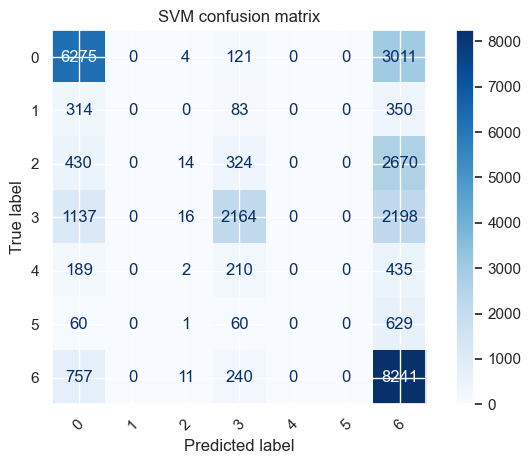

              precision    recall  f1-score   support

           0       0.68      0.67      0.68      9411
           1       0.00      0.00      0.00       747
           2       0.29      0.00      0.01      3438
           3       0.68      0.39      0.50      5515
           4       0.00      0.00      0.00       836
           5       0.00      0.00      0.00       750
           6       0.47      0.89      0.62      9249

    accuracy                           0.56     29946
   macro avg       0.30      0.28      0.26     29946
weighted avg       0.52      0.56      0.49     29946




======================= Decision Tree =======================


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


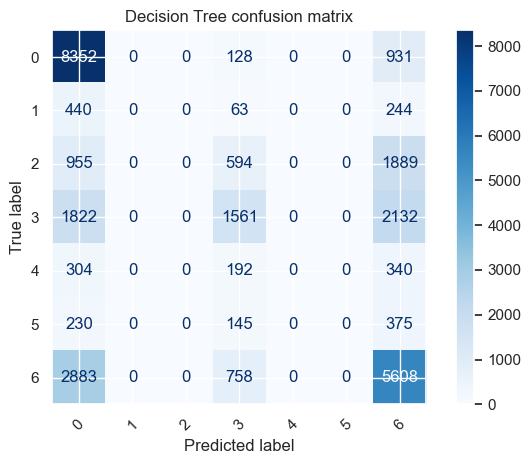

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.56      0.89      0.68      9411
           1       0.00      0.00      0.00       747
           2       0.00      0.00      0.00      3438
           3       0.45      0.28      0.35      5515
           4       0.00      0.00      0.00       836
           5       0.00      0.00      0.00       750
           6       0.49      0.61      0.54      9249

    accuracy                           0.52     29946
   macro avg       0.21      0.25      0.22     29946
weighted avg       0.41      0.52      0.45     29946




======================= Gaussian NB =======================


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


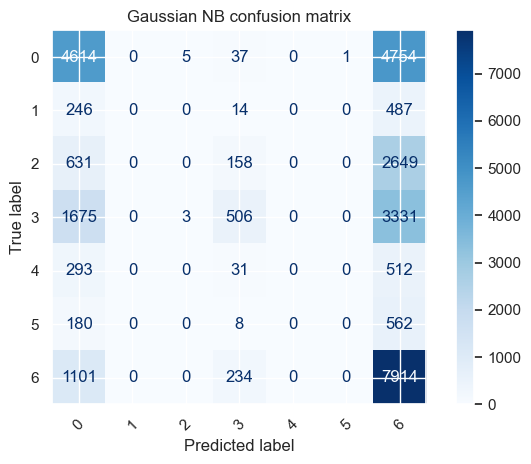

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.53      0.49      0.51      9411
           1       0.00      0.00      0.00       747
           2       0.00      0.00      0.00      3438
           3       0.51      0.09      0.16      5515
           4       0.00      0.00      0.00       836
           5       0.00      0.00      0.00       750
           6       0.39      0.86      0.54      9249

    accuracy                           0.44     29946
   macro avg       0.20      0.21      0.17     29946
weighted avg       0.38      0.44      0.35     29946




======================= Random Forest =======================


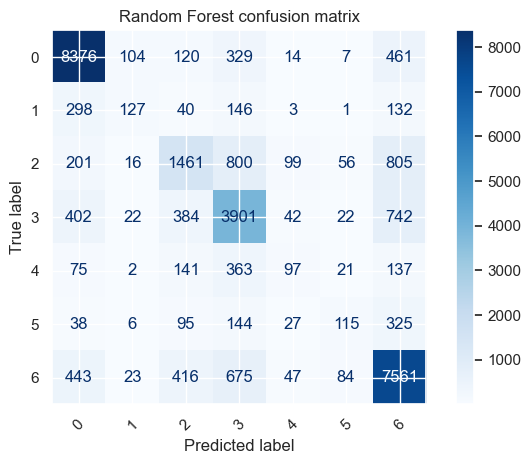

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      9411
           1       0.42      0.17      0.24       747
           2       0.55      0.42      0.48      3438
           3       0.61      0.71      0.66      5515
           4       0.29      0.12      0.17       836
           5       0.38      0.15      0.22       750
           6       0.74      0.82      0.78      9249

    accuracy                           0.72     29946
   macro avg       0.55      0.47      0.49     29946
weighted avg       0.70      0.72      0.71     29946




======================= AdaBoost =======================


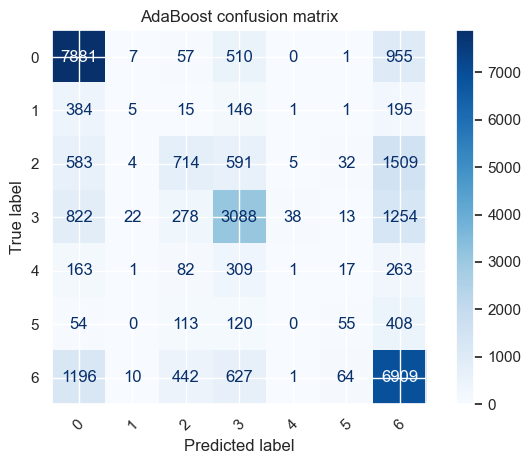

              precision    recall  f1-score   support

           0       0.71      0.84      0.77      9411
           1       0.10      0.01      0.01       747
           2       0.42      0.21      0.28      3438
           3       0.57      0.56      0.57      5515
           4       0.02      0.00      0.00       836
           5       0.30      0.07      0.12       750
           6       0.60      0.75      0.67      9249

    accuracy                           0.62     29946
   macro avg       0.39      0.35      0.34     29946
weighted avg       0.57      0.62      0.59     29946




======================= XGBoost =======================


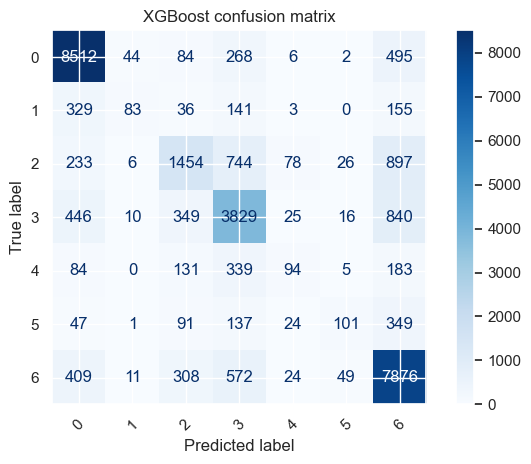

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      9411
           1       0.54      0.11      0.18       747
           2       0.59      0.42      0.49      3438
           3       0.63      0.69      0.66      5515
           4       0.37      0.11      0.17       836
           5       0.51      0.13      0.21       750
           6       0.73      0.85      0.79      9249

    accuracy                           0.73     29946
   macro avg       0.60      0.46      0.48     29946
weighted avg       0.71      0.73      0.71     29946






In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name, y_pred in [
    ('SVM', t_pred_svm),
    ('Decision Tree', t_pred_dt),
    ('Gaussian NB', t_pred_nb),
    ('Random Forest', t_pred_rf),
    ('AdaBoost', t_pred_ada),
    ('XGBoost', t_pred_xgb),
]:
    print(f'======================= {model_name} =======================')

    ConfusionMatrixDisplay.from_predictions(
        t_test,
        y_pred,
        cmap="Blues",
        xticks_rotation=45,
    )
    plt.title(model_name + ' confusion matrix')
    plt.tight_layout()
    plt.show()
    print(metrics.classification_report(t_test, y_pred))
    print('\n\n')

* 3.4 Confusion matrix visualizations (raw counts and row-normalized recall)

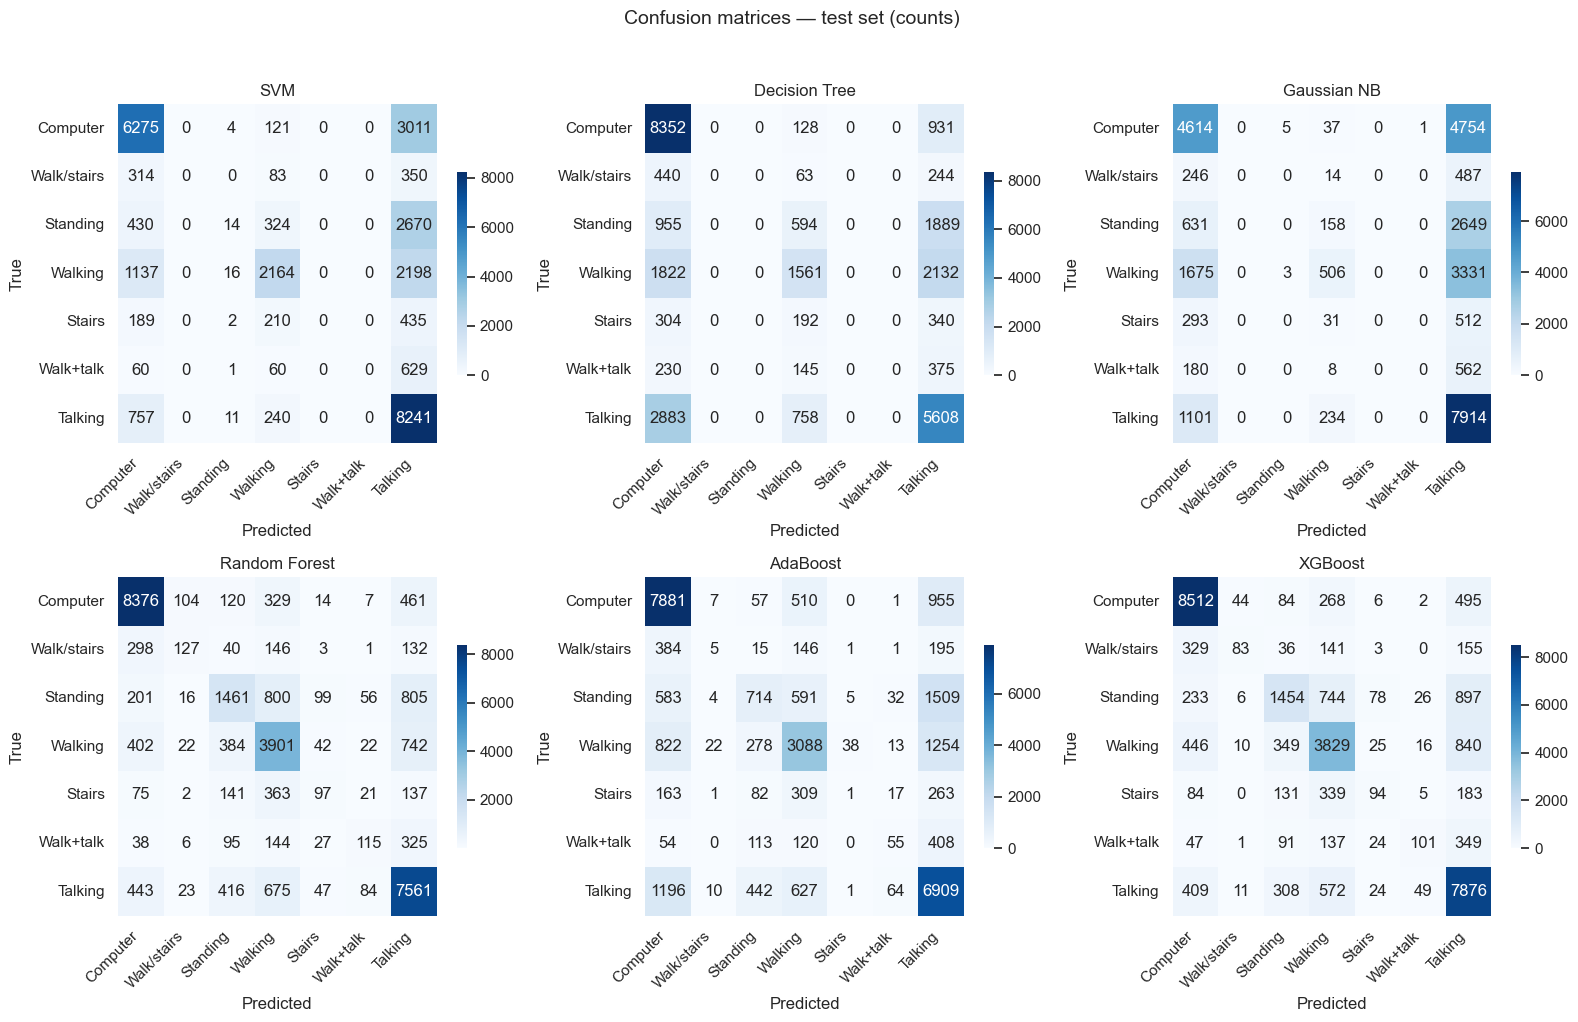

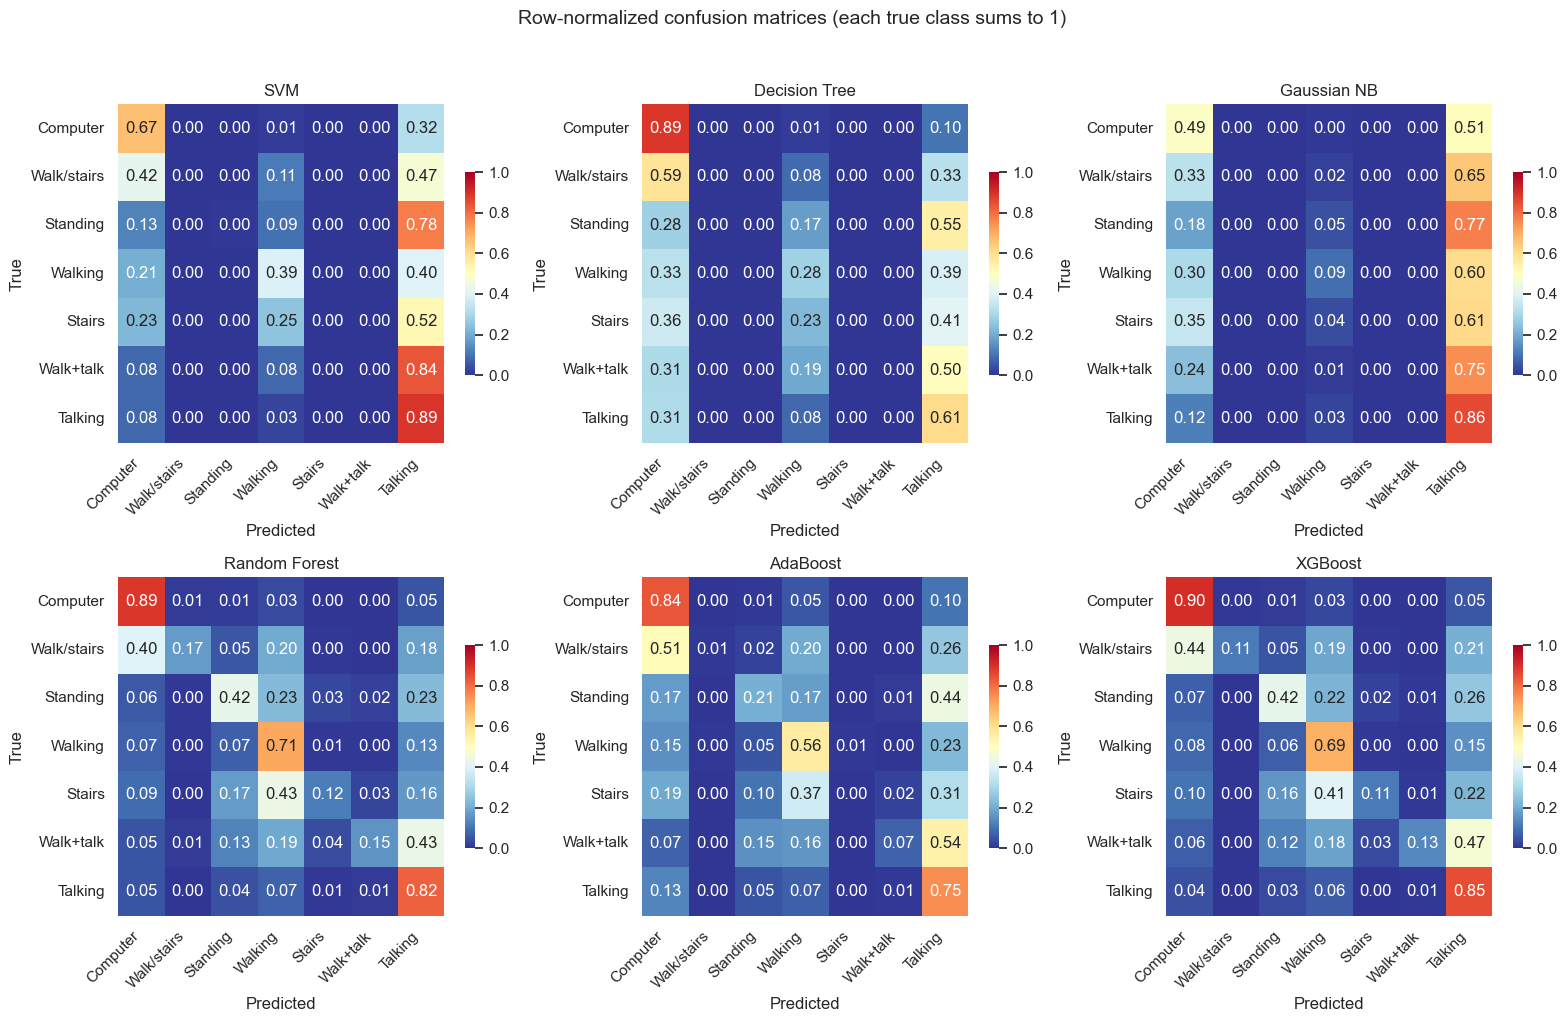

In [37]:
# Activity names (dataset labels 1–7) in LabelEncoder order (my_label.classes_)
SHORT_LABELS = {
    1: "Computer",
    2: "Walk/stairs",
    3: "Standing",
    4: "Walking",
    5: "Stairs",
    6: "Walk+talk",
    7: "Talking",
}
class_names = [SHORT_LABELS[int(x)] for x in my_label.classes_]

predictions = [
    ("SVM", t_pred_svm),
    ("Decision Tree", t_pred_dt),
    ("Gaussian NB", t_pred_nb),
    ("Random Forest", t_pred_rf),
    ("AdaBoost", t_pred_ada),
    ("XGBoost", t_pred_xgb),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (model_name, y_pred) in zip(axes.ravel(), predictions):
    cm = metrics.confusion_matrix(t_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names, rotation=0)
plt.suptitle("Confusion matrices — test set (counts)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
for ax, (model_name, y_pred) in zip(axes2.ravel(), predictions):
    cm = metrics.confusion_matrix(t_test, y_pred).astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="RdYlBu_r",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names, rotation=0)
plt.suptitle("Row-normalized confusion matrices (each true class sums to 1)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Across these models, the indicators of labels 4 and 5 are often weaker, while the other labels tend to perform better.